In [16]:
import pandas as pd 

df = pd.read_excel('synthetic_ecommerce_dataset_multisheet.xlsx')
print("Excel file loaded successfully!")

Excel file loaded successfully!


In [15]:
# Display the first 5 rows of the DataFrame 
print("=" * 60)
print("FIRST 5 ROWS OF THE DATAFRAME")
print("=" * 60)
print(df.head(5))

FIRST 5 ROWS OF THE DATAFRAME
   order_id  customer_id order_date product_category  order_value  \
0         1           76 2023-01-01             Home       103.87   
1         2          108 2023-01-02             Home       139.61   
2         3          156 2023-01-03            Books        81.76   
3         4           82 2023-01-04      Electronics        95.05   
4         5           77 2023-01-05         Clothing        39.99   

  payment_method  delivered  
0         Wallet          1  
1           Cash          1  
2           Cash          1  
3           Cash          1  
4    Credit Card          1  


In [30]:
import os
from dotenv import load_dotenv
load_dotenv()
# Connect to PostgreSQL database and insert the data from the DataFrame into a table named 'ecommerce_data'
from sqlalchemy import create_engine   
import pandas as pd
engine = create_engine(os.environ['DATABASE_URL'])
df.to_sql('ecommerce_data', engine, if_exists='replace', index=False)

# data insert to postgres , wich db, which table, which user, which password, which host, which port
print("=" * 60)
print("Data inserted into PostgreSQL database successfully!")
print("=" * 60)
print("\n")
print("Database: ", engine.url.database)
print("-" * 60)
print("Table: ", 'ecommerce_data')
print("-" * 60)
print("User: ", engine.url.username)
print("-" * 60)
print("Password: ", "hidden for security reasons")
print("-" * 60)
print("Host: ", engine.url.host)
print("-" * 60)
print("Port: ", engine.url.port)


Data inserted into PostgreSQL database successfully!


Database:  gerrik_db
------------------------------------------------------------
Table:  ecommerce_data
------------------------------------------------------------
User:  gerrik
------------------------------------------------------------
Password:  hidden for security reasons
------------------------------------------------------------
Host:  localhost
------------------------------------------------------------
Port:  5432


In [12]:
# Display summary statistics for numeric columns
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df.describe())

SUMMARY STATISTICS
          order_id  customer_id           order_date  order_value   delivered
count  1000.000000   1000.00000                 1000  1000.000000  1000.00000
mean    500.500000    145.22000  2024-05-14 12:00:00    47.727510     0.95400
min       1.000000      1.00000  2023-01-01 00:00:00     0.010000     0.00000
25%     250.750000     70.75000  2023-09-07 18:00:00    13.832500     1.00000
50%     500.500000    145.50000  2024-05-14 12:00:00    33.260000     1.00000
75%     750.250000    216.00000  2025-01-19 06:00:00    64.700000     1.00000
max    1000.000000    299.00000  2025-09-26 00:00:00   340.840000     1.00000
std     288.819436     85.09034                  NaN    46.861429     0.20959


In [10]:
# Duplicates Analysis
print("=" * 60)
print("DUPLICATESANALYSIS")
print("=" * 60)
print(df.duplicated().sum())
print(f"\nTotal rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

DUPLICATESANALYSIS
0

Total rows: 1000
Total columns: 7


In [5]:
# Missing Values Analysis
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")


MISSING VALUES ANALYSIS
order_id            0
customer_id         0
order_date          0
product_category    0
order_value         0
payment_method      0
delivered           0
dtype: int64

Total rows: 1000
Total columns: 7


In [6]:

# Correlation & Insights
print("\n" + "=" * 60)
print("KEY INSIGHTS & CORRELATIONS")
print("=" * 60)

# Delivery rate by category
print("\nDelivery Rate by Category:")
delivery_by_category = df.groupby('product_category')['delivered'].agg(['sum', 'count'])
delivery_by_category['delivery_rate'] = (delivery_by_category['sum'] / delivery_by_category['count'] * 100).round(2)
delivery_by_category.columns = ['Delivered', 'Total', 'Delivery_Rate_%']
print(delivery_by_category.sort_values('Delivery_Rate_%', ascending=False))

# Payment method reliability
print("\n" + "-" * 60)
print("Delivery Rate by Payment Method:")
delivery_by_payment = df.groupby('payment_method')['delivered'].agg(['sum', 'count'])
delivery_by_payment['delivery_rate'] = (delivery_by_payment['sum'] / delivery_by_payment['count'] * 100).round(2)
delivery_by_payment.columns = ['Delivered', 'Total', 'Delivery_Rate_%']
print(delivery_by_payment.sort_values('Delivery_Rate_%', ascending=False))



KEY INSIGHTS & CORRELATIONS

Delivery Rate by Category:
                  Delivered  Total  Delivery_Rate_%
product_category                                   
Home                    194    202            96.04
Electronics             198    207            95.65
Beauty                  181    190            95.26
Books                   181    190            95.26
Clothing                200    211            94.79

------------------------------------------------------------
Delivery Rate by Payment Method:
                Delivered  Total  Delivery_Rate_%
payment_method                                   
Credit Card           181    184            98.37
Cash                  215    222            96.85
Debit Card            180    190            94.74
Wallet                191    204            93.63
UPI                   187    200            93.50


/tmp/ipykernel_103506/1616665823.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, y='product_category', x='order_value', ax=axes[1], palette='Set2')


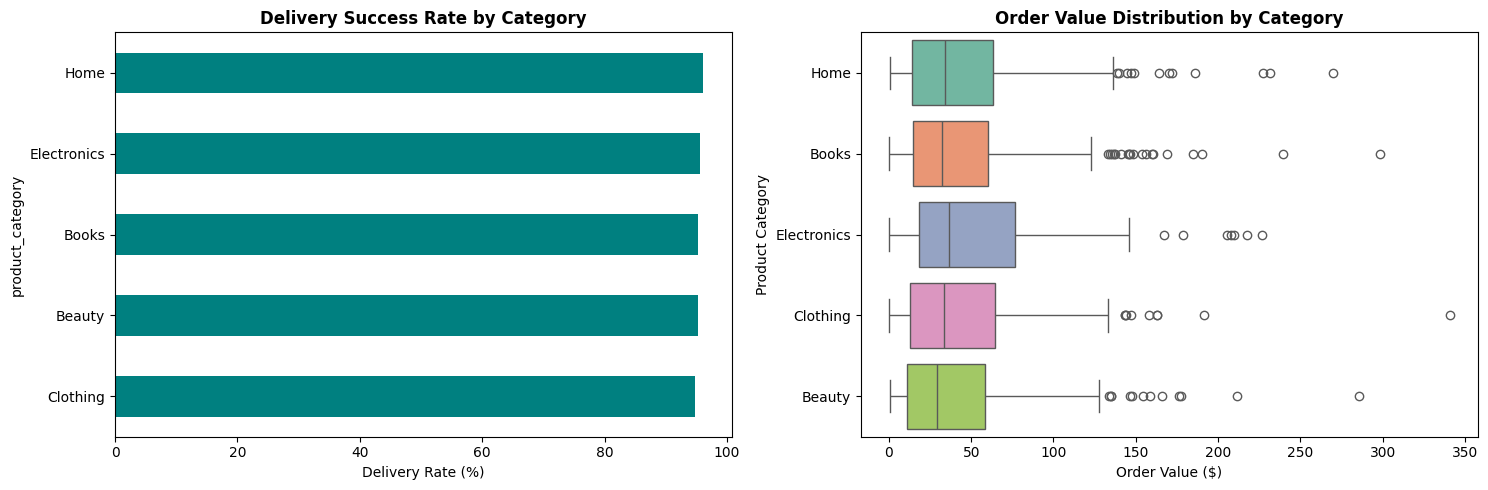

In [7]:
import seaborn as sns

# Visualization 3: Heatmap and Delivery Performance
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'sns' not in globals():
    import seaborn as sns
    
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Delivery Rate by Category
delivery_by_cat = df.groupby('product_category')['delivered'].apply(lambda x: (x.sum() / len(x) * 100))
delivery_by_cat.sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Delivery Success Rate by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Delivery Rate (%)')

# 2. Box plot - Order Value by Category
df_plot = df.copy()
sns.boxplot(data=df_plot, y='product_category', x='order_value', ax=axes[1], palette='Set2')
axes[1].set_title('Order Value Distribution by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Order Value ($)')
axes[1].set_ylabel('Product Category')

plt.tight_layout()
plt.show()


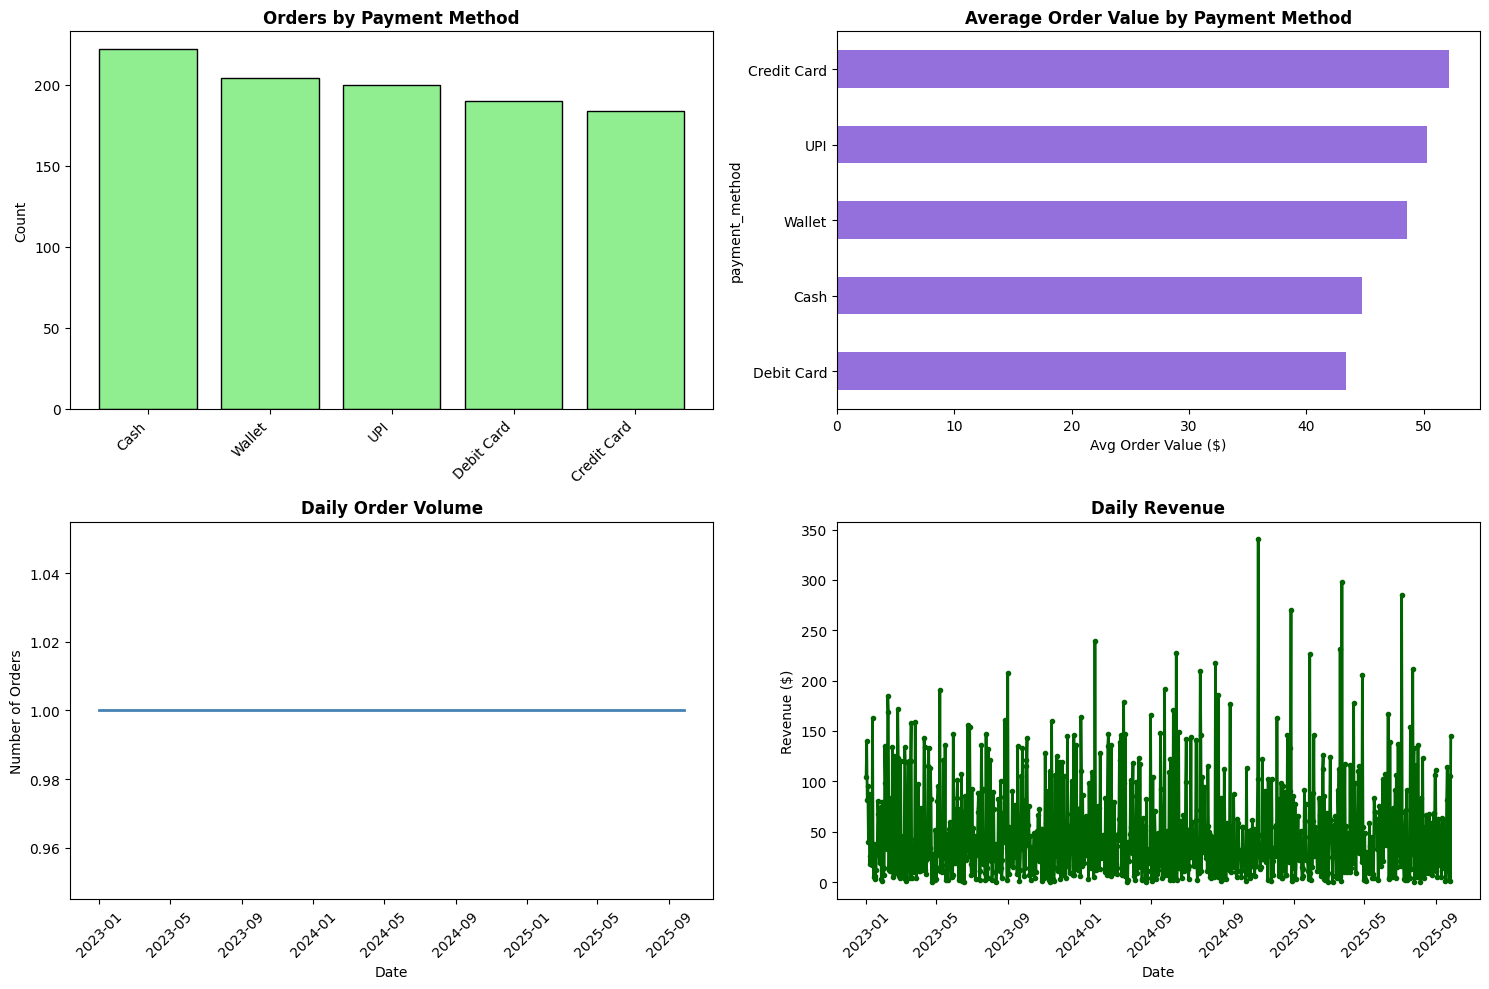

In [8]:

# Visualization 2: Payment Method and Time Series
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Payment Method Distribution
payment_dist = df['payment_method'].value_counts()
axes[0, 0].bar(range(len(payment_dist)), payment_dist.values, color='lightgreen', edgecolor='black')
axes[0, 0].set_xticks(range(len(payment_dist)))
axes[0, 0].set_xticklabels(payment_dist.index, rotation=45, ha='right')
axes[0, 0].set_title('Orders by Payment Method', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 2. Average Order Value by Payment Method
avg_by_payment = df.groupby('payment_method')['order_value'].mean().sort_values(ascending=True)
avg_by_payment.plot(kind='barh', ax=axes[0, 1], color='mediumpurple')
axes[0, 1].set_title('Average Order Value by Payment Method', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Avg Order Value ($)')

# 3. Daily Orders over Time
daily_orders = df.groupby(df['order_date'].dt.date).size()
axes[1, 0].plot(daily_orders.index, daily_orders.values, color='steelblue', linewidth=2)
axes[1, 0].set_title('Daily Order Volume', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Daily Revenue over Time
daily_revenue = df.groupby(df['order_date'].dt.date)['order_value'].sum()
axes[1, 1].plot(daily_revenue.index, daily_revenue.values, color='darkgreen', linewidth=2, marker='o', markersize=3)
axes[1, 1].set_title('Daily Revenue', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


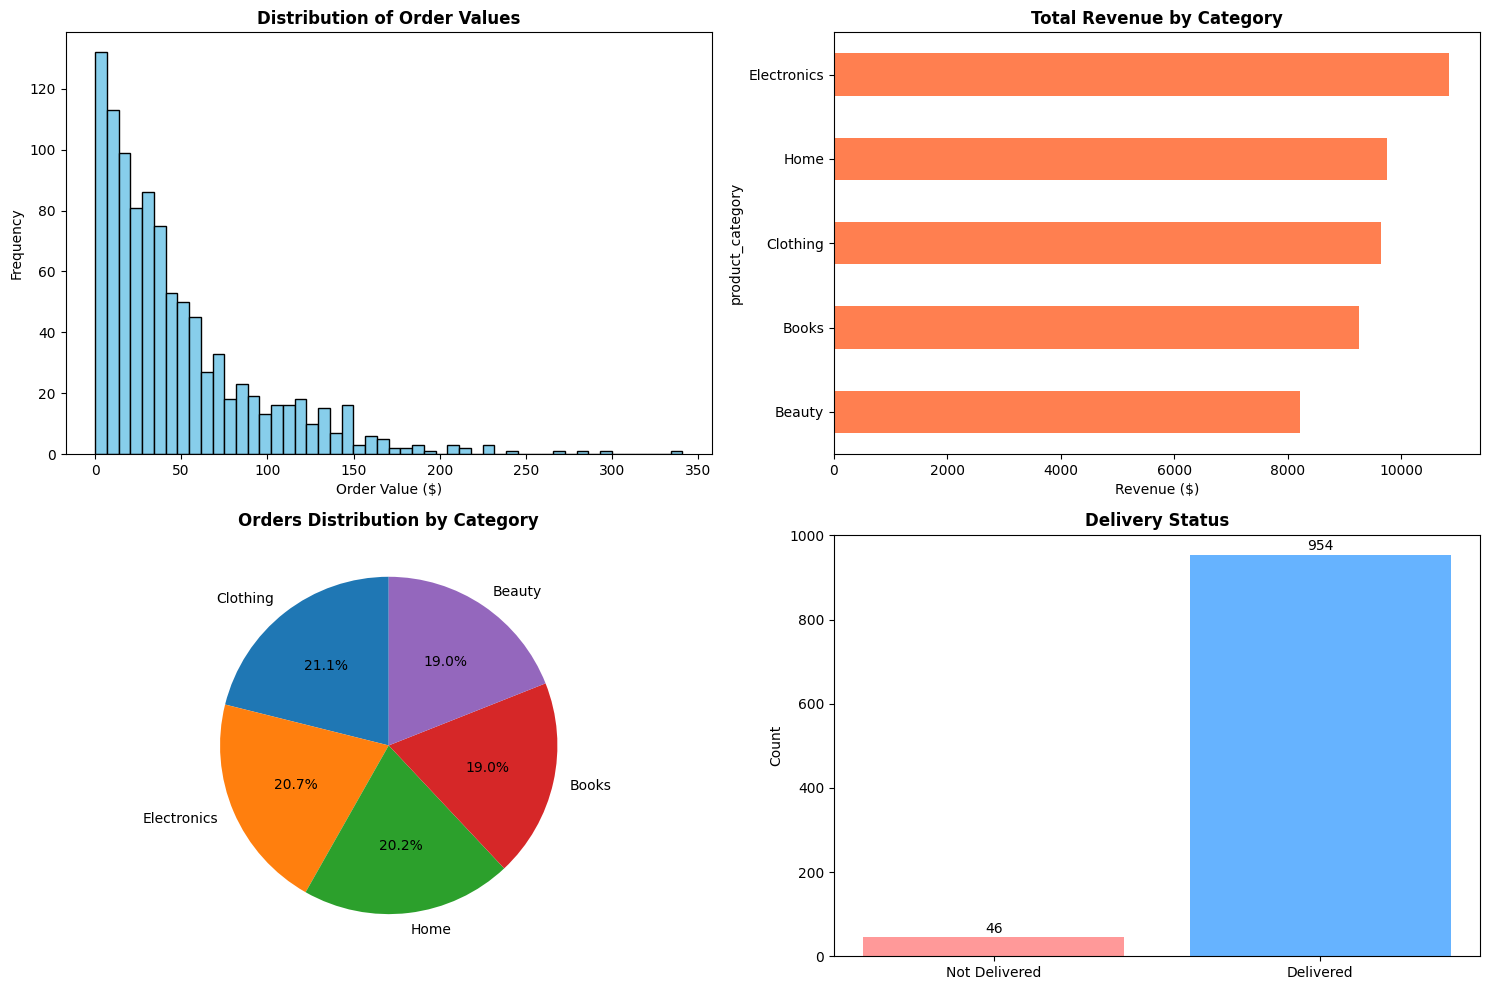

In [9]:

# Visualization 1: Revenue Distribution and Category Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Order Value Distribution
axes[0, 0].hist(df['order_value'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Order Values', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Order Value ($)')
axes[0, 0].set_ylabel('Frequency')

# 2. Revenue by Category
category_revenue = df.groupby('product_category')['order_value'].sum().sort_values(ascending=True)
category_revenue.plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Total Revenue by Category', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Revenue ($)')

# 3. Orders by Category
category_orders = df['product_category'].value_counts()
axes[1, 0].pie(category_orders.values, labels=category_orders.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Orders Distribution by Category', fontsize=12, fontweight='bold')

# 4. Delivery Status
delivery_status = df['delivered'].value_counts()
colors_delivery = ['#ff9999', '#66b3ff']
axes[1, 1].bar(['Not Delivered', 'Delivered'], [delivery_status.get(0, 0), delivery_status.get(1, 0)], color=colors_delivery)
axes[1, 1].set_title('Delivery Status', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate([delivery_status.get(0, 0), delivery_status.get(1, 0)]):
    axes[1, 1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()


In [10]:

# Time Series Analysis
print("\n" + "=" * 60)
print("TIME SERIES ANALYSIS")
print("=" * 60)
print(f"Date Range: {df['order_date'].min()} to {df['order_date'].max()}")
print(f"Days Covered: {(df['order_date'].max() - df['order_date'].min()).days} days")

# Daily revenue
daily_revenue = df.groupby(df['order_date'].dt.date).agg({
    'order_value': ['sum', 'count', 'mean']
})
daily_revenue.columns = ['Daily_Revenue', 'Order_Count', 'Avg_Order_Value']

print("\n" + "-" * 60)
print("Daily Revenue Statistics:")
print(f"Total Days with Orders: {len(daily_revenue)}")
print(f"Avg Daily Revenue: ${daily_revenue['Daily_Revenue'].mean():,.2f}")
print(f"Max Daily Revenue: ${daily_revenue['Daily_Revenue'].max():,.2f}")
print(f"Min Daily Revenue: ${daily_revenue['Daily_Revenue'].min():,.2f}")

# Monthly analysis
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('year_month').agg({
    'order_value': ['sum', 'count', 'mean'],
    'customer_id': 'nunique',
    'delivered': 'sum'
}).round(2)
monthly_revenue.columns = ['Total_Revenue', 'Order_Count', 'Avg_Order_Value', 'Unique_Customers', 'Delivered_Count']
print("\n" + "-" * 60)
print("Monthly Revenue Summary:")
print(monthly_revenue)



TIME SERIES ANALYSIS
Date Range: 2023-01-01 00:00:00 to 2025-09-26 00:00:00
Days Covered: 999 days

------------------------------------------------------------
Daily Revenue Statistics:
Total Days with Orders: 1000
Avg Daily Revenue: $47.73
Max Daily Revenue: $340.84
Min Daily Revenue: $0.01

------------------------------------------------------------
Monthly Revenue Summary:
            Total_Revenue  Order_Count  Avg_Order_Value  Unique_Customers  \
year_month                                                                  
2023-01           1374.87           31            44.35                29   
2023-02           1753.03           28            62.61                26   
2023-03           1619.85           31            52.25                30   
2023-04           1301.37           30            43.38                28   
2023-05           1381.18           31            44.55                31   
2023-06           1474.72           30            49.16                29   
20

In [11]:

# Customer Analysis
print("\n" + "=" * 60)
print("CUSTOMER ANALYSIS")
print("=" * 60)
print(f"Total Unique Customers: {df['customer_id'].nunique()}")
print(f"Total Orders: {len(df)}")
print(f"Avg Orders per Customer: {len(df) / df['customer_id'].nunique():.2f}")

print("\n" + "-" * 60)
print("Customer Segments (by spending):")
customer_spending = df.groupby('customer_id').agg({
    'order_value': ['count', 'sum', 'mean']
}).round(2)
customer_spending.columns = ['Order_Count', 'Total_Spent', 'Avg_Order_Value']
customer_spending = customer_spending.reset_index()

print(f"Top 5 Customers by Spending:")
print(customer_spending.nlargest(5, 'Total_Spent')[['customer_id', 'Order_Count', 'Total_Spent', 'Avg_Order_Value']])

print(f"\nCustomer Spending Statistics:")
print(f"Average Customer Lifetime Value: ${customer_spending['Total_Spent'].mean():,.2f}")
print(f"Median Customer Lifetime Value: ${customer_spending['Total_Spent'].median():,.2f}")
print(f"Max Customer Spending: ${customer_spending['Total_Spent'].max():,.2f}")



CUSTOMER ANALYSIS
Total Unique Customers: 281
Total Orders: 1000
Avg Orders per Customer: 3.56

------------------------------------------------------------
Customer Segments (by spending):
Top 5 Customers by Spending:
     customer_id  Order_Count  Total_Spent  Avg_Order_Value
240          255            8       901.19           112.65
250          265            4       629.40           157.35
23            26            7       623.26            89.04
156          166            9       541.07            60.12
26            29            8       524.62            65.58

Customer Spending Statistics:
Average Customer Lifetime Value: $169.85
Median Customer Lifetime Value: $145.99
Max Customer Spending: $901.19


In [12]:

# Delivery Analysis
print("\n" + "=" * 60)
print("DELIVERY PERFORMANCE ANALYSIS")
print("=" * 60)
delivery_rate = df['delivered'].value_counts()
print("\nDelivery Status Distribution:")
print(delivery_rate)

delivery_pct = (df['delivered'].value_counts(normalize=True) * 100).round(2)
print("\nDelivery Rate Percentage:")
for status, pct in delivery_pct.items():
    status_label = "Delivered" if status == 1 else "Not Delivered"
    print(f"{status_label}: {pct}%")

print("\n" + "-" * 60)
print("Revenue Impact of Delivery Status:")
revenue_by_delivery = df.groupby('delivered')['order_value'].agg(['sum', 'mean', 'count'])
revenue_by_delivery.index = ['Not Delivered', 'Delivered']
revenue_by_delivery.columns = ['Total Revenue', 'Avg Order Value', 'Order Count']
print(revenue_by_delivery)



DELIVERY PERFORMANCE ANALYSIS

Delivery Status Distribution:
delivered
1    954
0     46
Name: count, dtype: int64

Delivery Rate Percentage:
Delivered: 95.4%
Not Delivered: 4.6%

------------------------------------------------------------
Revenue Impact of Delivery Status:
               Total Revenue  Avg Order Value  Order Count
Not Delivered        2349.06        51.066522           46
Delivered           45378.45        47.566509          954


In [13]:

# Payment Method Analysis
print("\n" + "=" * 60)
print("PAYMENT METHOD ANALYSIS")
print("=" * 60)
payment_dist = df['payment_method'].value_counts()
print("\nPayment Method Distribution:")
print(payment_dist)
print("\nPayment Method Percentage:")
print((payment_dist / len(df) * 100).round(2))

print("\n" + "-" * 60)
print("Revenue by Payment Method:")
revenue_by_payment = df.groupby('payment_method')['order_value'].agg(['sum', 'mean', 'count'])
revenue_by_payment.columns = ['Total Revenue', 'Avg Order Value', 'Order Count']
print(revenue_by_payment.sort_values('Total Revenue', ascending=False))



PAYMENT METHOD ANALYSIS

Payment Method Distribution:
payment_method
Cash           222
Wallet         204
UPI            200
Debit Card     190
Credit Card    184
Name: count, dtype: int64

Payment Method Percentage:
payment_method
Cash           22.2
Wallet         20.4
UPI            20.0
Debit Card     19.0
Credit Card    18.4
Name: count, dtype: float64

------------------------------------------------------------
Revenue by Payment Method:
                Total Revenue  Avg Order Value  Order Count
payment_method                                             
UPI                  10051.06        50.255300          200
Cash                  9936.00        44.756757          222
Wallet                9906.03        48.558971          204
Credit Card           9599.40        52.170652          184
Debit Card            8235.02        43.342211          190


In [14]:

# Revenue Analysis
print("\n" + "=" * 60)
print("REVENUE ANALYSIS")
print("=" * 60)
print(f"Total Revenue: ${df['order_value'].sum():,.2f}")
print(f"Average Order Value: ${df['order_value'].mean():,.2f}")
print(f"Median Order Value: ${df['order_value'].median():,.2f}")
print(f"Min Order Value: ${df['order_value'].min():,.2f}")
print(f"Max Order Value: ${df['order_value'].max():,.2f}")
print(f"Revenue Std Dev: ${df['order_value'].std():,.2f}")



REVENUE ANALYSIS
Total Revenue: $47,727.51
Average Order Value: $47.73
Median Order Value: $33.26
Min Order Value: $0.01
Max Order Value: $340.84
Revenue Std Dev: $46.86


In [15]:

# Category Analysis
print("\n" + "=" * 60)
print("PRODUCT CATEGORY ANALYSIS")
print("=" * 60)
category_stats = df['product_category'].value_counts()
print("\nOrders by Category:")
print(category_stats)
print(f"\nTotal Categories: {df['product_category'].nunique()}")

# Revenue by Category
print("\n" + "-" * 60)
print("Revenue by Category:")
revenue_by_category = df.groupby('product_category')['order_value'].agg(['sum', 'mean', 'count'])
revenue_by_category.columns = ['Total Revenue', 'Avg Order Value', 'Order Count']
print(revenue_by_category.sort_values('Total Revenue', ascending=False))



PRODUCT CATEGORY ANALYSIS

Orders by Category:
product_category
Clothing       211
Electronics    207
Home           202
Books          190
Beauty         190
Name: count, dtype: int64

Total Categories: 5

------------------------------------------------------------
Revenue by Category:
                  Total Revenue  Avg Order Value  Order Count
product_category                                             
Electronics            10848.50        52.408213          207
Home                    9756.01        48.297079          202
Clothing                9645.18        45.711754          211
Books                   9257.56        48.724000          190
Beauty                  8220.26        43.264526          190


In [16]:

# Data Type Conversion
df['order_date'] = pd.to_datetime(df['order_date'])
print("\n" + "=" * 60)
print("DATA TYPES AFTER CONVERSION")
print("=" * 60)
print(df.dtypes)



DATA TYPES AFTER CONVERSION
order_id                     int64
customer_id                  int64
order_date          datetime64[us]
product_category               str
order_value                float64
payment_method                 str
delivered                    int64
year_month               period[M]
dtype: object
